In [1]:
#pip install kagglehub

In [2]:
#import kagglehub

# Download latest version
#path = kagglehub.dataset_download("yogape/logistics-operations-database")

#print("Path to dataset files:", path)

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

In [ ]:
# revenue per truck, cost per mile, driver efficiency rankings, maintenance spend by equipment age, customer concentration risk.
#cost-per-mile analysis, fleet utilization optimization, driver performance scorecards.
#predictive models for maintenance scheduling, driver retention
#Build models forecasting equipment failures based on maintenance history, predict driver turnover using performance metrics, estimate route profitability for new lanes.
#calculate ideal fleet size, evaluate driver-to-truck


   # Which routes generate the highest profit margin after fuel costs?
    #How does driver tenure correlate with fuel efficiency and on-time performance?
    #What's the optimal preventive maintenance interval to minimize total cost of ownership?
    #Which customers have the highest revenue-per-load and best payment terms?
    #How do seasonal patterns affect equipment utilization and revenue?
    #What safety incident patterns exist by driver experience level?
    #Which city pairs have the most reliable on-time delivery performance?
    #How does truck age impact maintenance costs and downtime?
    



# Reading Data into the Pandas Dataframe

In [3]:
drivers= pd.read_csv('C:/Users/safam/Downloads/logistics project/drivers.csv')
safety_incidents =pd.read_csv("C:/Users/safam/.cache/kagglehub/datasets/yogape/logistics-operations-database/versions/1/safety_incidents.csv")
performance = pd.read_csv('C:/Users/safam/Downloads/logistics project/driver_monthly_metrics.csv')


# Checking the data 

In [4]:
drivers.head()

,driver_id,first_name,last_name,gender,hire_date,termination_date,license_number,license_state,date_of_birth,home_terminal,employment_status,cdl_class,years_experience,age
0,DRV00001,Jennifer,Hernandez,F,10/31/2014,NaN,DL673510887,WA,11/7/1973,Denver,Active,A,3,51
1,DRV00002,William,Martin,M,10/2/2020,NaN,DL128955006,GA,11/3/1976,Columbus,Active,A,20,48
2,DRV00003,Charles,Hernandez,M,9/21/2021,NaN,DL523076025,NC,4/6/1970,Salt Lake City,Active,A,19,54
3,DRV00004,Barbara,Brown,F,9/8/2013,NaN,DL735540030,WA,2/6/1995,Denver,Active,A,19,29
4,DRV00005,Mary,Martinez,F,12/2/2018,NaN,DL706011277,AZ,7/15/1960,Chicago,Active,A,12,64


In [5]:
safety_incidents.head()

,incident_id,trip_id,truck_id,driver_id,incident_date,incident_type,location_city,location_state,at_fault_flag,injury_flag,vehicle_damage_cost,cargo_damage_cost,claim_amount,preventable_flag,description
0,INC00000001,TRIP00036079,TRK00006,DRV00006,2023-04-09 14:00:00,Moving Violation,Columbus,PA,True,False,12629.26,0.00,12629.26,True,Severe incident involving equipment
1,INC00000002,TRIP00032462,TRK00084,DRV00006,2023-02-19 11:00:00,Moving Violation,Columbus,NC,False,False,2700.70,14284.24,16984.94,False,Severe incident involving weather
2,INC00000003,TRIP00067583,TRK00106,DRV00119,2024-05-20 01:00:00,Customer Complaint,Seattle,OK,True,False,24302.32,0.00,24302.32,True,Minor incident involving traffic
3,INC00000004,TRIP00049128,TRK00085,DRV00134,2023-09-26 03:00:00,Equipment Damage,Kansas City,TN,True,False,4879.13,0.00,4879.13,True,Moderate incident involving equipment
4,INC00000005,TRIP00062884,TRK00014,DRV00133,2024-03-20 14:00:00,DOT Violation,Las Vegas,IN,False,False,14951.40,0.00,14951.40,False,Minor incident involving other driver


In [6]:
performance.head()

,driver_id,month,trips_completed,total_miles,total_revenue,average_mpg,total_fuel_gallons,on_time_delivery_rate,average_idle_hours
0,DRV00001,2022-01-01,26,36620,79141.59,6.61,5574.7,0.385,8.2
1,DRV00001,2022-02-01,9,13515,27133.87,6.69,2095.1,0.333,6.8
2,DRV00001,2022-03-01,20,30361,62399.62,6.36,4792.2,0.550,7.5
3,DRV00001,2022-04-01,19,28127,68161.13,6.61,4251.4,0.474,8.4
4,DRV00001,2022-05-01,14,16071,36256.82,6.35,2573.1,0.214,6.8


# Descriptive Statistics

In [7]:
drivers.describe()

,years_experience,age
count,150.000000,150.000000
mean,13.493333,45.180000
std,6.958889,9.960371
min,2.000000,29.000000
25%,7.250000,36.000000
50%,13.500000,45.000000
75%,20.000000,54.000000
max,25.000000,64.000000


In [8]:
safety_incidents.describe()

,vehicle_damage_cost,cargo_damage_cost,claim_amount
count,170.000000,170.000000,170.000000
mean,9432.712412,6174.180647,15606.893059
std,8549.031425,12989.250393,15082.128331
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,2108.275000
50%,8035.265000,0.000000,13627.185000
75%,17688.742500,1790.562500,21988.787500
max,24614.160000,49744.070000,64245.720000


In [9]:
performance.describe()

,trips_completed,total_miles,total_revenue,average_mpg,total_fuel_gallons,on_time_delivery_rate,average_idle_hours
count,4464.000000,4464.000000,4464.000000,4464.000000,4464.000000,4464.000000,4464.000000
mean,18.749104,26812.792339,57630.947713,6.501862,4158.631698,0.445996,7.011738
std,4.387080,7253.534265,15899.349196,0.140353,1132.037704,0.119988,0.683257
min,5.000000,3310.000000,7096.560000,6.010000,521.900000,0.000000,4.400000
25%,16.000000,21783.000000,46314.052500,6.410000,3372.500000,0.364000,6.600000
50%,19.000000,26409.500000,56652.715000,6.500000,4083.950000,0.444000,7.000000
75%,22.000000,31474.750000,67964.807500,6.600000,4882.400000,0.526000,7.500000
max,37.000000,57954.000000,124579.530000,7.070000,9007.500000,0.833000,9.700000


# Checking for Nulls and Duplicates

In [10]:
drivers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   driver_id          150 non-null    object
 1   first_name         150 non-null    object
 2   last_name          150 non-null    object
 3   gender             150 non-null    object
 4   hire_date          150 non-null    object
 5   termination_date   26 non-null     object
 6   license_number     150 non-null    object
 7   license_state      150 non-null    object
 8   date_of_birth      150 non-null    object
 9   home_terminal      150 non-null    object
 10  employment_status  150 non-null    object
 11  cdl_class          150 non-null    object
 12  years_experience   150 non-null    int64 
 13  age                150 non-null    int64 
dtypes: int64(2), object(12)
memory usage: 16.5+ KB


In [11]:
safety_incidents.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170 entries, 0 to 169
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   incident_id          170 non-null    object 
 1   trip_id              170 non-null    object 
 2   truck_id             169 non-null    object 
 3   driver_id            169 non-null    object 
 4   incident_date        170 non-null    object 
 5   incident_type        170 non-null    object 
 6   location_city        170 non-null    object 
 7   location_state       170 non-null    object 
 8   at_fault_flag        170 non-null    bool   
 9   injury_flag          170 non-null    bool   
 10  vehicle_damage_cost  170 non-null    float64
 11  cargo_damage_cost    170 non-null    float64
 12  claim_amount         170 non-null    float64
 13  preventable_flag     170 non-null    bool   
 14  description          170 non-null    object 
dtypes: bool(3), float64(3), object(9)
memory

In [12]:
performance.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4464 entries, 0 to 4463
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   driver_id              4464 non-null   object 
 1   month                  4464 non-null   object 
 2   trips_completed        4464 non-null   int64  
 3   total_miles            4464 non-null   int64  
 4   total_revenue          4464 non-null   float64
 5   average_mpg            4464 non-null   float64
 6   total_fuel_gallons     4464 non-null   float64
 7   on_time_delivery_rate  4464 non-null   float64
 8   average_idle_hours     4464 non-null   float64
dtypes: float64(5), int64(2), object(2)
memory usage: 314.0+ KB


# Deleting duplicate columns, if any

In [13]:
print(drivers.duplicated().sum())
print(safety_incidents.duplicated().sum())
#print(trips.duplicated().sum())
print(performance.duplicated().sum())

0
0
0


# Creating a new 'Incidents' Table

In [14]:
incidents = safety_incidents.dropna(subset=['driver_id'])

In [15]:
incidents.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 169 entries, 0 to 169
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   incident_id          169 non-null    object 
 1   trip_id              169 non-null    object 
 2   truck_id             168 non-null    object 
 3   driver_id            169 non-null    object 
 4   incident_date        169 non-null    object 
 5   incident_type        169 non-null    object 
 6   location_city        169 non-null    object 
 7   location_state       169 non-null    object 
 8   at_fault_flag        169 non-null    bool   
 9   injury_flag          169 non-null    bool   
 10  vehicle_damage_cost  169 non-null    float64
 11  cargo_damage_cost    169 non-null    float64
 12  claim_amount         169 non-null    float64
 13  preventable_flag     169 non-null    bool   
 14  description          169 non-null    object 
dtypes: bool(3), float64(3), object(9)
memory

In [16]:
#trips = trips.dropna(subset=['driver_id'])

In [17]:
#trips.info()

# Creating a new 'driver_incident_counts' table

In [18]:
driver_incident_counts = incidents['driver_id'].value_counts().reset_index()

driver_incident_counts.columns = ['driver_id', 'incident_counts']


In [19]:
performance.head()

,driver_id,month,trips_completed,total_miles,total_revenue,average_mpg,total_fuel_gallons,on_time_delivery_rate,average_idle_hours
0,DRV00001,2022-01-01,26,36620,79141.59,6.61,5574.7,0.385,8.2
1,DRV00001,2022-02-01,9,13515,27133.87,6.69,2095.1,0.333,6.8
2,DRV00001,2022-03-01,20,30361,62399.62,6.36,4792.2,0.550,7.5
3,DRV00001,2022-04-01,19,28127,68161.13,6.61,4251.4,0.474,8.4
4,DRV00001,2022-05-01,14,16071,36256.82,6.35,2573.1,0.214,6.8


In [20]:
#trips_count = trips.groupby('driver_id').agg(
 #   total_hours=('actual_duration_hours', 'sum'),
  #  total_idle_hours=('idle_time_hours', 'sum')
#)

# Creating a new 'driver_perf' table

In [21]:
driver_perf = performance.groupby('driver_id').agg(
    avg_revenue = ('total_revenue','mean'),
    avg_mpg = ('average_mpg','mean'),
    on_time_rate = ('on_time_delivery_rate','mean'),
    avg_idle_hours =('average_idle_hours','mean')
)

In [22]:
#trips_count.head()

In [23]:
driver_perf.head()

,avg_revenue,avg_mpg,on_time_rate,avg_idle_hours
driver_id,,,,
DRV00001,55157.868333,6.484722,0.454167,7.036111
DRV00002,57600.597222,6.505000,0.468389,7.108333
DRV00003,59638.263056,6.539444,0.450806,6.797222
DRV00004,58871.151389,6.517222,0.428333,7.002778
DRV00005,56176.596111,6.512222,0.454056,7.136111


In [24]:
#trips_count['idle_driving_ratio']=round(trips_count['total_idle_hours']*100/trips_count['total_hours'],2)

In [25]:
driver_incident_counts.head()

,driver_id,incident_counts
0,DRV00058,7
1,DRV00003,6
2,DRV00006,3
3,DRV00121,3
4,DRV00018,3


In [26]:
#trips_count.head()

# Creating a new 'drivers' table with merge 

In [27]:
drivers = pd.merge(drivers, driver_incident_counts, on='driver_id', how='left')


In [28]:
drivers = pd.merge(drivers, driver_perf, on='driver_id', how='left')

In [29]:
drivers.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 150 entries, 0 to 149
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   driver_id          150 non-null    object 
 1   first_name         150 non-null    object 
 2   last_name          150 non-null    object 
 3   gender             150 non-null    object 
 4   hire_date          150 non-null    object 
 5   termination_date   26 non-null     object 
 6   license_number     150 non-null    object 
 7   license_state      150 non-null    object 
 8   date_of_birth      150 non-null    object 
 9   home_terminal      150 non-null    object 
 10  employment_status  150 non-null    object 
 11  cdl_class          150 non-null    object 
 12  years_experience   150 non-null    int64  
 13  age                150 non-null    int64  
 14  incident_counts    92 non-null     float64
 15  avg_revenue        124 non-null    float64
 16  avg_mpg            124 non

In [30]:
#----> do imputation instead::: drivers['incident_counts'] = drivers['incident_counts'].fillna(0.0)
#drivers['idle_driving_ratio'] = drivers['incident_counts'].fillna(0)

In [31]:
drivers.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 150 entries, 0 to 149
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   driver_id          150 non-null    object 
 1   first_name         150 non-null    object 
 2   last_name          150 non-null    object 
 3   gender             150 non-null    object 
 4   hire_date          150 non-null    object 
 5   termination_date   26 non-null     object 
 6   license_number     150 non-null    object 
 7   license_state      150 non-null    object 
 8   date_of_birth      150 non-null    object 
 9   home_terminal      150 non-null    object 
 10  employment_status  150 non-null    object 
 11  cdl_class          150 non-null    object 
 12  years_experience   150 non-null    int64  
 13  age                150 non-null    int64  
 14  incident_counts    150 non-null    float64
 15  avg_revenue        124 non-null    float64
 16  avg_mpg            124 non

In [32]:
drivers.head()

,driver_id,first_name,last_name,gender,hire_date,termination_date,license_number,license_state,date_of_birth,home_terminal,employment_status,cdl_class,years_experience,age,incident_counts,avg_revenue,avg_mpg,on_time_rate,avg_idle_hours
0,DRV00001,Jennifer,Hernandez,F,10/31/2014,NaN,DL673510887,WA,11/7/1973,Denver,Active,A,3,51,1.0,55157.868333,6.484722,0.454167,7.036111
1,DRV00002,William,Martin,M,10/2/2020,NaN,DL128955006,GA,11/3/1976,Columbus,Active,A,20,48,2.0,57600.597222,6.505000,0.468389,7.108333
2,DRV00003,Charles,Hernandez,M,9/21/2021,NaN,DL523076025,NC,4/6/1970,Salt Lake City,Active,A,19,54,6.0,59638.263056,6.539444,0.450806,6.797222
3,DRV00004,Barbara,Brown,F,9/8/2013,NaN,DL735540030,WA,2/6/1995,Denver,Active,A,19,29,2.0,58871.151389,6.517222,0.428333,7.002778
4,DRV00005,Mary,Martinez,F,12/2/2018,NaN,DL706011277,AZ,7/15/1960,Chicago,Active,A,12,64,2.0,56176.596111,6.512222,0.454056,7.136111


In [33]:
drivers['termination_date'] = drivers['termination_date'].fillna('12/31/2024')

In [34]:
drivers.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 150 entries, 0 to 149
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   driver_id          150 non-null    object 
 1   first_name         150 non-null    object 
 2   last_name          150 non-null    object 
 3   gender             150 non-null    object 
 4   hire_date          150 non-null    object 
 5   termination_date   150 non-null    object 
 6   license_number     150 non-null    object 
 7   license_state      150 non-null    object 
 8   date_of_birth      150 non-null    object 
 9   home_terminal      150 non-null    object 
 10  employment_status  150 non-null    object 
 11  cdl_class          150 non-null    object 
 12  years_experience   150 non-null    int64  
 13  age                150 non-null    int64  
 14  incident_counts    150 non-null    float64
 15  avg_revenue        124 non-null    float64
 16  avg_mpg            124 non

# Formatting the drivers table 

In [35]:
drivers['hire_date'] = pd.to_datetime(drivers['hire_date'], format='%m/%d/%Y')
drivers['termination_date'] = pd.to_datetime(drivers['termination_date'], format='%m/%d/%Y')



In [36]:
drivers['tenure'] = round((drivers['termination_date'] - drivers['hire_date']) / np.timedelta64(1, 'Y'), 0)

In [37]:
drivers.head()

,driver_id,first_name,last_name,gender,hire_date,termination_date,license_number,license_state,date_of_birth,home_terminal,employment_status,cdl_class,years_experience,age,incident_counts,avg_revenue,avg_mpg,on_time_rate,avg_idle_hours,tenure
0,DRV00001,Jennifer,Hernandez,F,2014-10-31,2024-12-31,DL673510887,WA,11/7/1973,Denver,Active,A,3,51,1.0,55157.868333,6.484722,0.454167,7.036111,10.0
1,DRV00002,William,Martin,M,2020-10-02,2024-12-31,DL128955006,GA,11/3/1976,Columbus,Active,A,20,48,2.0,57600.597222,6.505000,0.468389,7.108333,4.0
2,DRV00003,Charles,Hernandez,M,2021-09-21,2024-12-31,DL523076025,NC,4/6/1970,Salt Lake City,Active,A,19,54,6.0,59638.263056,6.539444,0.450806,6.797222,3.0
3,DRV00004,Barbara,Brown,F,2013-09-08,2024-12-31,DL735540030,WA,2/6/1995,Denver,Active,A,19,29,2.0,58871.151389,6.517222,0.428333,7.002778,11.0
4,DRV00005,Mary,Martinez,F,2018-12-02,2024-12-31,DL706011277,AZ,7/15/1960,Chicago,Active,A,12,64,2.0,56176.596111,6.512222,0.454056,7.136111,6.0


In [38]:
drivers['total_yoe'] = drivers['years_experience']+drivers['tenure']

In [39]:
drivers.head()

,driver_id,first_name,last_name,gender,hire_date,termination_date,license_number,license_state,date_of_birth,home_terminal,...,cdl_class,years_experience,age,incident_counts,avg_revenue,avg_mpg,on_time_rate,avg_idle_hours,tenure,total_yoe
0,DRV00001,Jennifer,Hernandez,F,2014-10-31,2024-12-31,DL673510887,WA,11/7/1973,Denver,...,A,3,51,1.0,55157.868333,6.484722,0.454167,7.036111,10.0,13.0
1,DRV00002,William,Martin,M,2020-10-02,2024-12-31,DL128955006,GA,11/3/1976,Columbus,...,A,20,48,2.0,57600.597222,6.505000,0.468389,7.108333,4.0,24.0
2,DRV00003,Charles,Hernandez,M,2021-09-21,2024-12-31,DL523076025,NC,4/6/1970,Salt Lake City,...,A,19,54,6.0,59638.263056,6.539444,0.450806,6.797222,3.0,22.0
3,DRV00004,Barbara,Brown,F,2013-09-08,2024-12-31,DL735540030,WA,2/6/1995,Denver,...,A,19,29,2.0,58871.151389,6.517222,0.428333,7.002778,11.0,30.0
4,DRV00005,Mary,Martinez,F,2018-12-02,2024-12-31,DL706011277,AZ,7/15/1960,Chicago,...,A,12,64,2.0,56176.596111,6.512222,0.454056,7.136111,6.0,18.0


In [40]:
drivers.drop(columns= ['first_name','last_name','hire_date','termination_date','license_number','date_of_birth','cdl_class','license_state','home_terminal','years_experience',], inplace=True)

In [41]:
drivers.head()

,driver_id,gender,employment_status,age,incident_counts,avg_revenue,avg_mpg,on_time_rate,avg_idle_hours,tenure,total_yoe
0,DRV00001,F,Active,51,1.0,55157.868333,6.484722,0.454167,7.036111,10.0,13.0
1,DRV00002,M,Active,48,2.0,57600.597222,6.505000,0.468389,7.108333,4.0,24.0
2,DRV00003,M,Active,54,6.0,59638.263056,6.539444,0.450806,6.797222,3.0,22.0
3,DRV00004,F,Active,29,2.0,58871.151389,6.517222,0.428333,7.002778,11.0,30.0
4,DRV00005,F,Active,64,2.0,56176.596111,6.512222,0.454056,7.136111,6.0,18.0


# Feature Engineering: Identifying continuous and categorical features in the drivers table

In [52]:
continuous_features = ['age','avg_revenue','avg_mpg','on_time_rate','avg_idle_hours','total_yoe']

In [55]:
categorical_features = ['gender', 'incident_counts']

# Label Encoder is called and used on the drivers table

In [43]:
le= LabelEncoder()

In [44]:
drivers['status_encoded'] = le.fit_transform(drivers['employment_status'])

In [45]:
drivers.head()

,driver_id,gender,employment_status,age,incident_counts,avg_revenue,avg_mpg,on_time_rate,avg_idle_hours,tenure,total_yoe,status_encoded
0,DRV00001,F,Active,51,1.0,55157.868333,6.484722,0.454167,7.036111,10.0,13.0,0
1,DRV00002,M,Active,48,2.0,57600.597222,6.505000,0.468389,7.108333,4.0,24.0,0
2,DRV00003,M,Active,54,6.0,59638.263056,6.539444,0.450806,6.797222,3.0,22.0,0
3,DRV00004,F,Active,29,2.0,58871.151389,6.517222,0.428333,7.002778,11.0,30.0,0
4,DRV00005,F,Active,64,2.0,56176.596111,6.512222,0.454056,7.136111,6.0,18.0,0


In [46]:
drivers.describe()

,age,incident_counts,avg_revenue,avg_mpg,on_time_rate,avg_idle_hours,tenure,total_yoe,status_encoded
count,150.000000,150.000000,124.000000,124.000000,124.000000,124.000000,150.0000,150.000000,150.000000
mean,45.180000,1.126667,57630.947713,6.501862,0.445996,7.011738,6.6200,20.113333,0.173333
std,9.960371,1.200093,2952.256483,0.024645,0.020261,0.109920,3.5477,8.132738,0.379803
min,29.000000,0.000000,48607.379444,6.442222,0.365194,6.677778,1.0000,4.000000,0.000000
25%,36.000000,0.000000,55627.165625,6.485347,0.434972,6.954861,4.0000,14.000000,0.000000
50%,45.000000,1.000000,58003.136528,6.499167,0.444292,7.016667,6.0000,20.500000,0.000000
75%,54.000000,2.000000,59713.446250,6.516111,0.459000,7.077778,10.0000,26.000000,0.000000
max,64.000000,7.000000,64217.897222,6.563056,0.507667,7.350000,13.0000,37.000000,1.000000


# Continuous Features are mapped

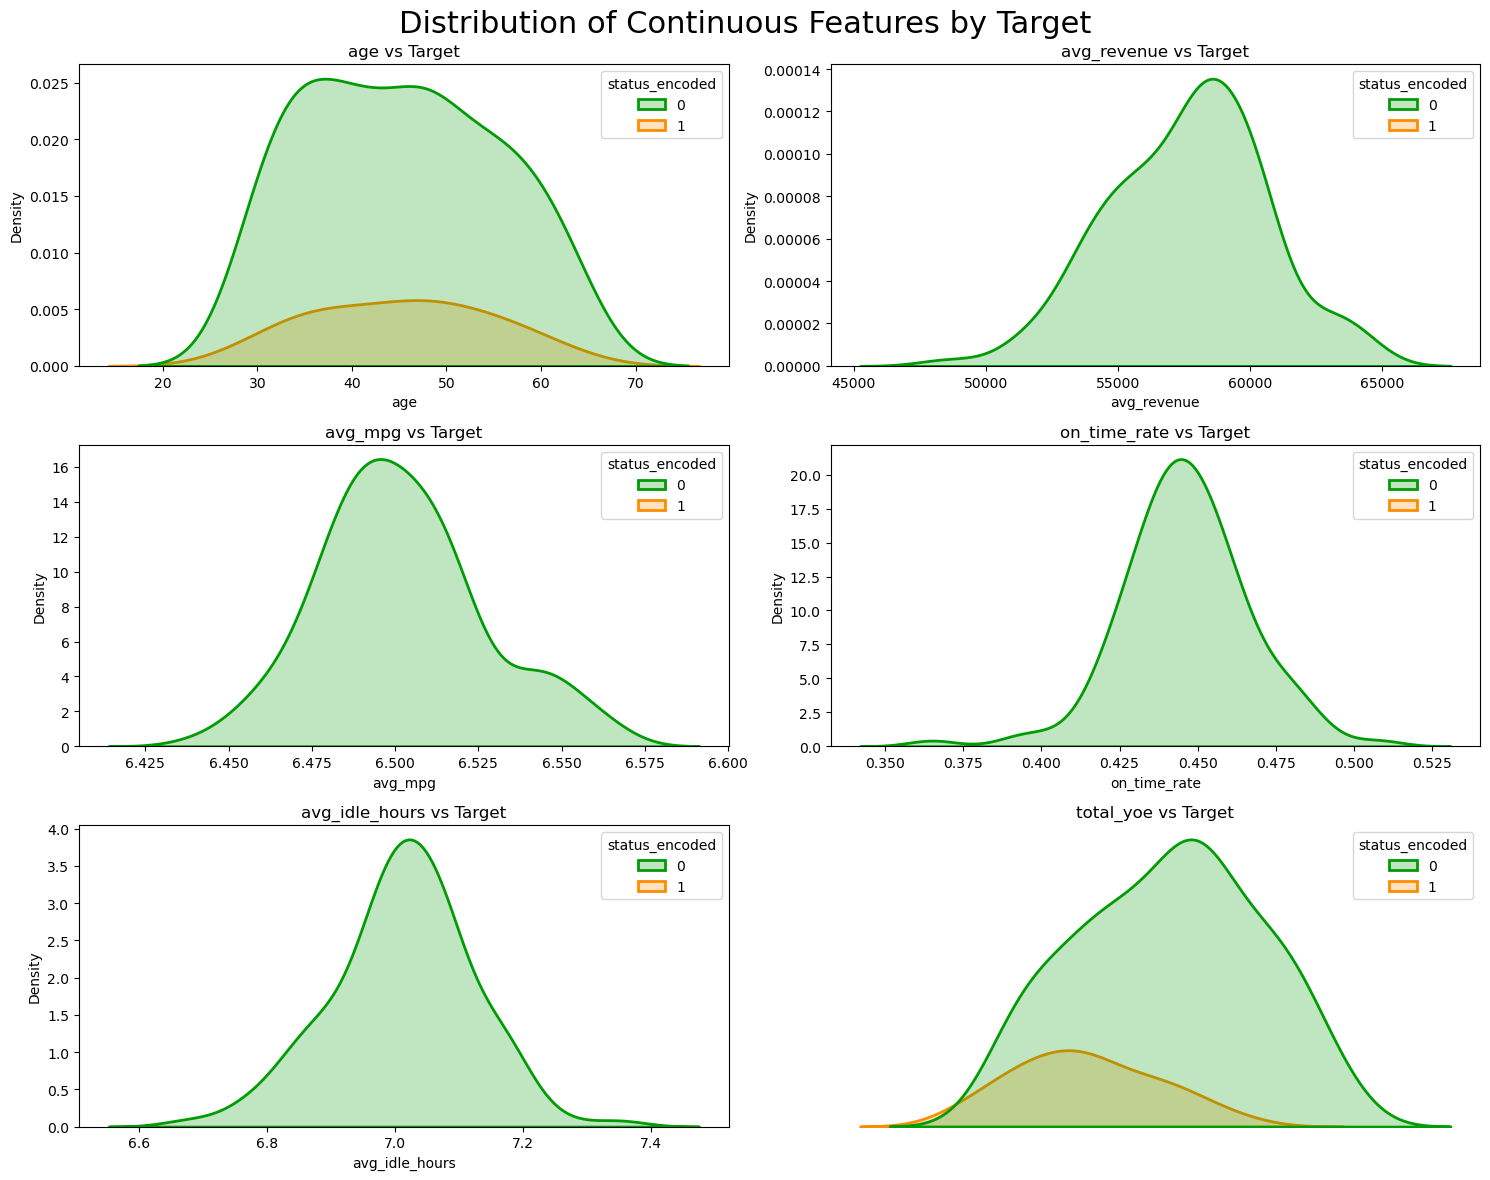

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns
# Create subplots for kde plots
fig, axes = plt.subplots(3, 2, figsize=(15, 12))

for ax, col in zip(axes.flatten(), continuous_features):
    sns.kdeplot(data=drivers, x=col, fill=True, linewidth=2, hue='status_encoded', ax=ax, palette = {0: '#009c05', 1: 'darkorange'})
    ax.set_title(f'{col} vs Target')

axes[2,1].axis('off')
plt.suptitle('Distribution of Continuous Features by Target', fontsize=22)
plt.tight_layout()
plt.show()

# Categorical Features are mapped

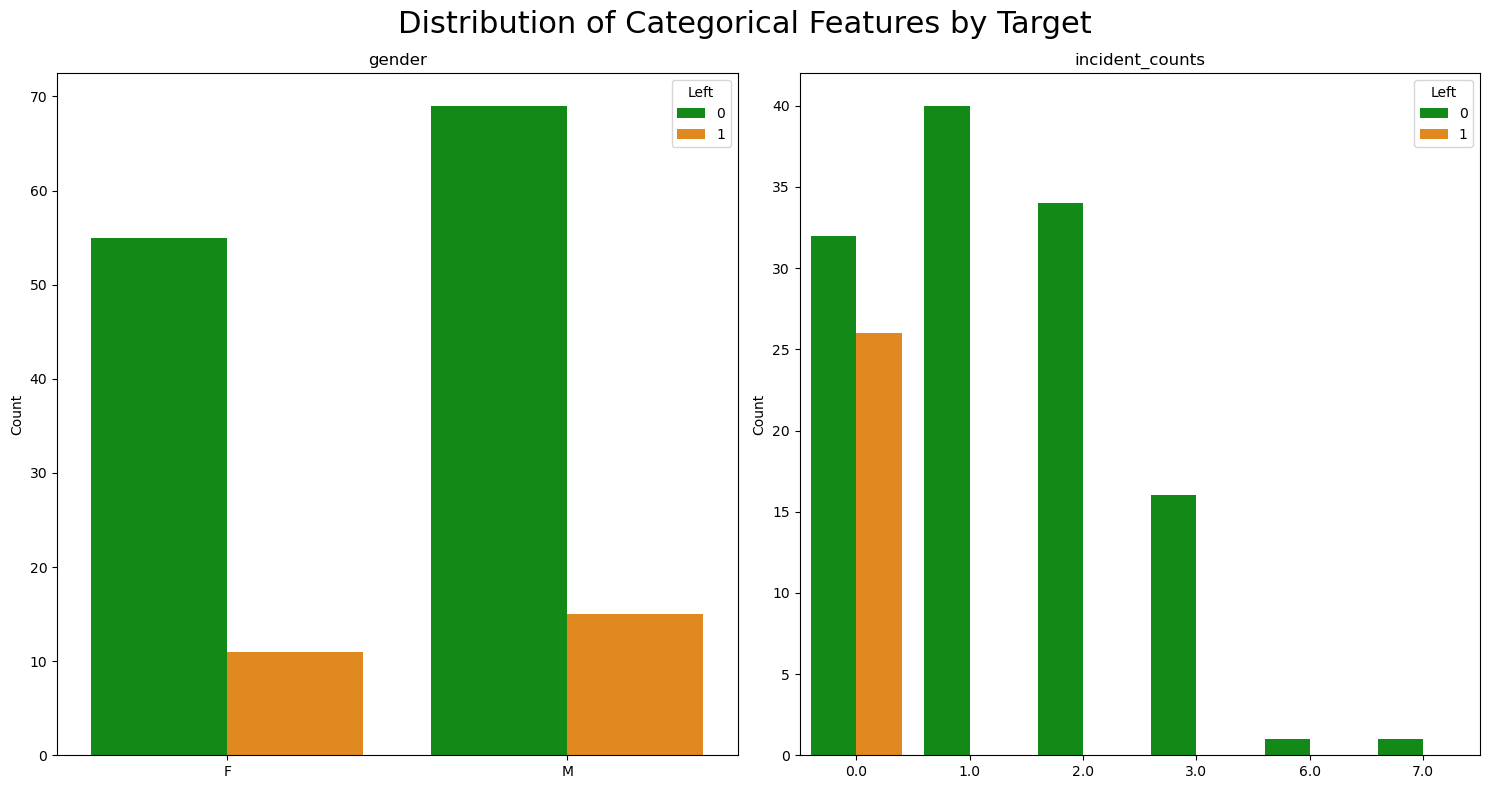

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(15, 8))

# Plot each feature
for i, ax in enumerate(axes.flatten()):
    sns.countplot(x=categorical_features[i], hue='status_encoded', data=drivers, ax=ax, palette={0: '#009c05', 1: 'darkorange'})
    ax.set_title(categorical_features[i])
    ax.set_ylabel('Count')
    ax.set_xlabel('')
    ax.legend(title='Left', loc='upper right')

plt.suptitle('Distribution of Categorical Features by Target', fontsize=22)
plt.tight_layout()
plt.show()

# Logistic Regression

In [57]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer

##
Numerical variables:
    avg_mpg
    avg_idle_hours
    on_time_rate
    avg_revenure
    total_yoe
    age
categoical 
    incident counts: low(0-1), med(2-4) high(5-7)
binary variables:
    status_encoded
    gender
   --> incident_history

# Gender is encoded 

In [58]:
drivers['gender_enc'] = le.fit_transform(drivers['gender'])


In [60]:
mapping = {0: 0, 1: 0, 2: 1, 3:1, 4:1, 5:2, 6:2, 7:2 }

In [61]:
drivers['incidents_encoded'] = drivers['incident_counts'].replace(mapping)

In [62]:
drivers.head()

,driver_id,gender,employment_status,age,incident_counts,avg_revenue,avg_mpg,on_time_rate,avg_idle_hours,tenure,total_yoe,status_encoded,gender_enc,incidents_encoded
0,DRV00001,F,Active,51,1.0,55157.868333,6.484722,0.454167,7.036111,10.0,13.0,0,0,0.0
1,DRV00002,M,Active,48,2.0,57600.597222,6.505000,0.468389,7.108333,4.0,24.0,0,1,1.0
2,DRV00003,M,Active,54,6.0,59638.263056,6.539444,0.450806,6.797222,3.0,22.0,0,1,2.0
3,DRV00004,F,Active,29,2.0,58871.151389,6.517222,0.428333,7.002778,11.0,30.0,0,0,1.0
4,DRV00005,F,Active,64,2.0,56176.596111,6.512222,0.454056,7.136111,6.0,18.0,0,0,1.0


In [66]:
drivers =drivers.drop(['incident_counts','tenure','employment_status','gender'], axis=1)

In [70]:
drivers= drivers.drop(['driver_id'], axis=1)

In [71]:
drivers.head()

,age,avg_revenue,avg_mpg,on_time_rate,avg_idle_hours,total_yoe,status_encoded,gender_enc,incidents_encoded
0,51,55157.868333,6.484722,0.454167,7.036111,13.0,0,0,0.0
1,48,57600.597222,6.505000,0.468389,7.108333,24.0,0,1,1.0
2,54,59638.263056,6.539444,0.450806,6.797222,22.0,0,1,2.0
3,29,58871.151389,6.517222,0.428333,7.002778,30.0,0,0,1.0
4,64,56176.596111,6.512222,0.454056,7.136111,18.0,0,0,1.0


In [72]:
X = drivers.drop('status_encoded', axis=1)
y = drivers['status_encoded']

# Model is split and empty values are imputed using simple imputer. Accuracy of the model through this method is identified. 

In [75]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Imputation Method:
# Impute missing values with mean
imputer = SimpleImputer(strategy='mean')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# Train logistic regression model
model_imputed = LogisticRegression()
model_imputed.fit(X_train_imputed, y_train)

# Evaluate model on test set
accuracy_imputed = model_imputed.score(X_test_imputed, y_test)
print("Accuracy with Imputation Method:", accuracy_imputed)

Accuracy with Imputation Method: 0.8333333333333334


In [77]:
from sklearn.metrics import accuracy_score

print('Accuracy Score Test:', accuracy_score(y_test, model_imputed.predict(X_test_imputed))*100)


Accuracy Score Test: 83.33333333333334
